In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pairinteraction.real as pi
from pairinteraction import perturbative
from pairinteraction.units import ureg

logger = logging.getLogger(__name__)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

pi.Database.initialize_global_database()

In [2]:
n = 80
ket1 = pi.KetAtom("Sr88_singlet", n=n, l=0, j=0, m=0)
ket2 = pi.KetAtom("Sr88_singlet", n=n + 1, l=0, j=0, m=0)
ket3 = pi.KetAtom("Sr88_singlet", n=n, l=1, j=1, m=0)

eff_h = perturbative.EffectiveHamiltonian([(ket1, ket2), (ket2, ket1)])

eff_h.set_perturbation_order(2)

eff_h.set_magnetic_field([0, 0, 50], "gauss")
eff_h.set_electric_field([0, 0, 0.2], "V/cm")

eff_h.set_interaction_order(3)
eff_h.set_distance(10, angle_degree=0, unit="micrometer")

eff_h.create_basis_atoms()
eff_h.create_system_atoms()
eff_h.create_basis_pair_from_number_of_kets(2_000)
eff_h.create_system_pair()

eff_h.create_resonances_lists()

2025-06-03 11:21:27,170 INFO Using database directory: /itp3/home/moegerle/.cache/pairinteraction/database
2025-06-03 11:21:27,172 INFO Asset            Local     Remote
2025-06-03 11:21:27,172 INFO -----------------------------------
2025-06-03 11:21:27,172 INFO Cs               v1.1  >   N/A
2025-06-03 11:21:27,173 INFO Li               v1.0  >   N/A
2025-06-03 11:21:27,173 INFO Na               v1.0  >   N/A
2025-06-03 11:21:27,173 INFO Rb               v1.1  >   N/A
2025-06-03 11:21:27,174 INFO Sr87_mqdt        v1.0  >   N/A
2025-06-03 11:21:27,174 INFO Sr88_mqdt        v1.0  >   N/A
2025-06-03 11:21:27,174 INFO Sr88_singlet     v1.1  >   N/A
2025-06-03 11:21:27,174 INFO Sr88_triplet     v1.1  >   N/A
2025-06-03 11:21:27,175 INFO Yb171_mqdt       v1.0  >   N/A
2025-06-03 11:21:27,176 INFO Yb173_mqdt       v1.0  >   N/A
2025-06-03 11:21:27,176 INFO Yb174_mqdt       v1.0  >   N/A
2025-06-03 11:21:27,176 INFO misc             v1.1  >   N/A


In [3]:
hartree_to_ghz = ureg.Quantity(1, "hartree").to("GHz", "spectroscopy").magnitude

labels = np.array([ket.get_label("ket") for ket in eff_h._all_ket_pairs])
labels = [label.replace(ket1.species + ":", "") for label in labels]

# sort by energy gap
gaps = eff_h._all_gaps_au[1, :] * hartree_to_ghz
couplings = np.abs(eff_h._all_couplings_au)[1, :] * hartree_to_ghz

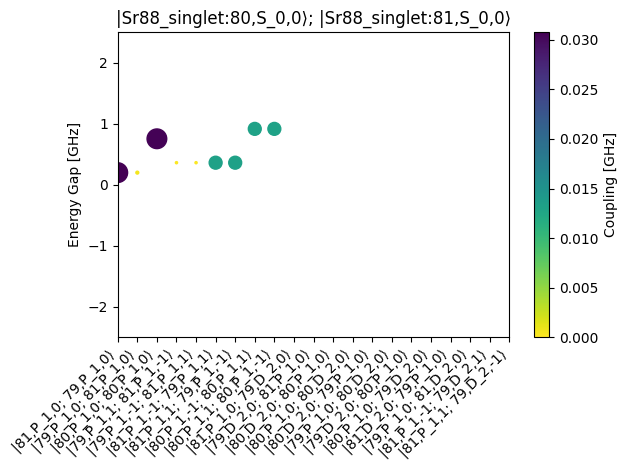

In [4]:
fig, ax = plt.subplots()

x = np.arange(len(labels))
colors = couplings
sizes = 1 + (colors / np.max(colors)) * 200
scatter = ax.scatter(
    x,
    gaps,
    s=sizes,
    c=colors,
    cmap="viridis_r",  # "afmhot_r",
    vmin=0,
)
plt.colorbar(scatter, label=r"Coupling [GHz]")

ax.set_xticks(x, labels, rotation=45, ha="right")
ax.set_xlabel(None)
ax.set_xlim(0, 20)
ax.set_ylim(-2.5, 2.5)
ax.set_ylabel("Energy Gap [GHz]")
ax.set_title(f"{ket1}; {ket2}")
fig.tight_layout()
plt.show()

120


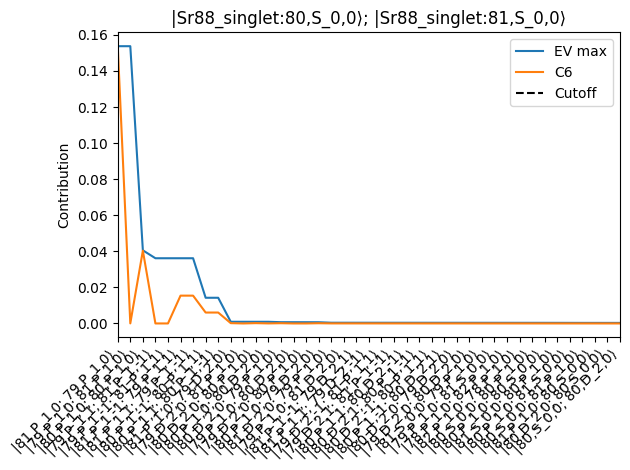

In [5]:
fig, ax = plt.subplots()

x = np.arange(len(labels))

ev_contributions = np.abs(couplings / gaps)
c6_contributions = np.abs(couplings**2 / gaps)
c6_contributions = c6_contributions / np.max(c6_contributions) * np.max(ev_contributions)

cutoff = np.argmax(eff_h._all_ev_contributions_max < 1e-5)
print(cutoff)

ax.plot(x, eff_h._all_ev_contributions_max, label="EV max")
ax.plot(x, c6_contributions, label="C6")
ax.axvline(cutoff, color="k", linestyle="--", label="Cutoff")
ax.legend()

ax.set_xticks(x, labels, rotation=45, ha="right")
ax.set_xlabel(None)
ax.set_ylabel("Contribution")
ax.set_title(f"{ket1}; {ket2}")

ax.set_xlim(0, 40)

fig.tight_layout()
plt.show()